In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.axes3d import Axes3D
from mpl_toolkits.mplot3d.proj3d import proj_transform

plt.rcParams.update({"text.usetex": True, "mathtext.fontset": "dejavuserif"})

In [2]:
N = 50
bounds_avg = np.loadtxt("bounds_mean.csv", delimiter=",")
bounds_std = np.loadtxt("bounds_std.csv", delimiter=",")
bounds_avg = bounds_avg[:N+1, :N+1]
bounds_std = bounds_std[:N+1, :N+1]
colors = ["#4053d3", "#ddb310", "#b51d14", "#00beff", "#fb49b0", "#00b25d"]
ns = [12, 18, 24, 30, 36]
ks = [12, 18, 24, 30, 36]

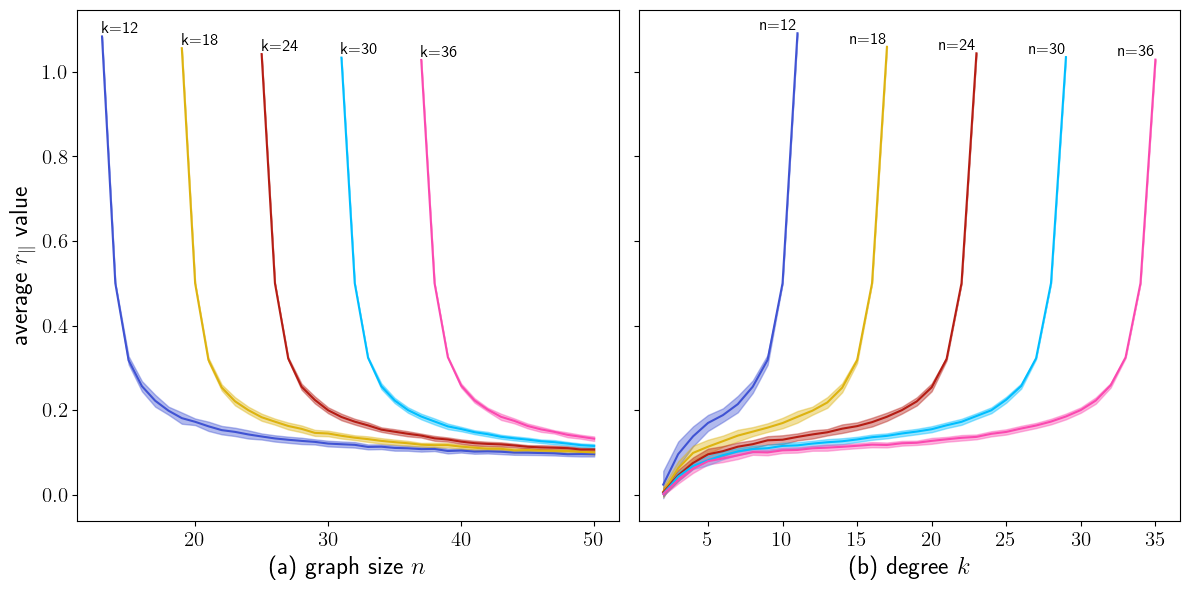

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

label_fontsize = 18
tick_fontsize = 15

# left: r_parallel vs graph size n for fixed k
for idx, k in enumerate(ks):
    axes[0].plot(np.arange(N+1), bounds_avg[:, k], color=colors[idx])
    axes[0].fill_between(
        np.arange(N+1),
        bounds_avg[:, k] - bounds_std[:, k],
        bounds_avg[:, k] + bounds_std[:, k],
        alpha=0.4,
        color=colors[idx],
    )
    axes[0].text(k+1, (k+1)/k, f"k={k}", fontsize=12, color="black", va="bottom", ha="left")
axes[0].set_xlabel(r"(a) graph size $n$", fontsize=label_fontsize)
axes[0].set_ylabel(r"average $r_\parallel$ value", fontsize=label_fontsize)
axes[0].tick_params(axis='both', which='major', labelsize=tick_fontsize)

# right: r_parallel vs degree d for fixed n
for idx, n in enumerate(ns):
    axes[1].plot(np.arange(N+1), bounds_avg[n, :], color=colors[idx])
    axes[1].fill_between(
        np.arange(N+1),
        bounds_avg[n, :] - bounds_std[n, :],
        bounds_avg[n, :] + bounds_std[n, :],
        alpha=0.4,
        color=colors[idx],
    )
    axes[1].text(n - 1, n/(n-1), f"n={n}", fontsize=12, color="black", va="bottom", ha="right")
axes[1].set_xlabel(r"(b) degree $k$", fontsize=label_fontsize)
axes[1].tick_params(axis='both', which='major', labelsize=tick_fontsize)

plt.tight_layout()
plt.savefig("../images/regular-n-k.png", bbox_inches="tight", dpi=600)
plt.show()